#  P003 — Behavioral Biometric Authentication System
## Touchscreen Gesture-Based Continuous Authentication

> **Module:** Computer & Network Security  
> **Topic:** Behavioral Biometrics — Touchscreen Gestures  
> **Dataset:** 912,133 touch events · 5 users · 41 sessions  
> **Models:** Isolation Forest & One-Class SVM  
> **Key Metrics:** FAR, FRR, EER, AUC-ROC  

---
###  Notebook Outline
1. Setup & Imports
2. Data Loading & Exploration
3. Exploratory Data Analysis (EDA)
4. Feature Engineering (19 features per gesture)
5. User Profiling — Train/Test Split
6. Anomaly Detection (One-Class Models)
7. FAR & FRR Threshold Analysis
8. Evaluation: ROC, EER, Confusion Matrices
9. Results Summary & Conclusions


---
## 1. Setup & Imports

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.15)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})
print(' Libraries loaded.')

 Libraries loaded.


---
## 2. Data Loading & Schema Discovery

In [5]:
COL_NAMES = [
    'user_id', 'session_id', 'gesture_id',
    'timestamp', 'event_type', 'pointer_id',
    'x', 'y', 'pressure', 'size', 'orientation'
]

#  Update DATA_PATH to your CSV location
DATA_PATH = 'data_cns.csv'

df = pd.read_csv(DATA_PATH, header=None, names=COL_NAMES)

print(f'Shape         : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Users         : {sorted(df.user_id.unique())}')
print(f'Sessions/user : {df.groupby("user_id")["session_id"].nunique().to_dict()}')
print(f'Memory        : {df.memory_usage(deep=True).sum()/1e6:.1f} MB')
df.head()

Shape         : 912,133 rows × 11 columns
Users         : [0, 1, 2, 3, 4]
Sessions/user : {0: 6, 1: 15, 2: 13, 3: 3, 4: 4}
Memory        : 80.3 MB


,user_id,session_id,gesture_id,timestamp,event_type,pointer_id,x,y,pressure,size,orientation
0,0,36,3,1334893336544,0,1,272,269,0.21,0.044444,0.0
1,0,36,3,1334893336790,2,1,262,271,0.32,0.044444,0.0
2,0,36,3,1334893336795,2,1,123,327,0.28,0.044444,0.0
3,0,36,3,1334893336800,1,1,123,327,0.28,0.044444,0.0
4,0,36,3,1334893336885,0,1,216,298,0.34,0.044444,0.0


In [7]:
# Data types, missing values, ranges
pd.DataFrame({
    'dtype'  : df.dtypes,
    'missing': df.isnull().sum(),
    'unique' : df.nunique(),
    'min'    : df.min(),
    'max'    : df.max()
})

,dtype,missing,unique,min,max
user_id,int64,0,5,0.000000e+00,4.000000e+00
session_id,int64,0,41,0.000000e+00,4.000000e+01
gesture_id,int64,0,7,0.000000e+00,6.000000e+00
timestamp,int64,0,911579,1.334330e+12,1.336104e+12
event_type,int64,0,3,0.000000e+00,2.000000e+00
pointer_id,int64,0,2,1.000000e+00,2.000000e+00
x,int64,0,555,-8.000000e+00,5.550000e+02
y,int64,0,569,-3.100000e+01,5.380000e+02
pressure,float64,0,221,2.352941e-02,1.340000e+00
size,float64,0,40,2.222223e-02,6.666667e-01


---
## 3. Exploratory Data Analysis (EDA)

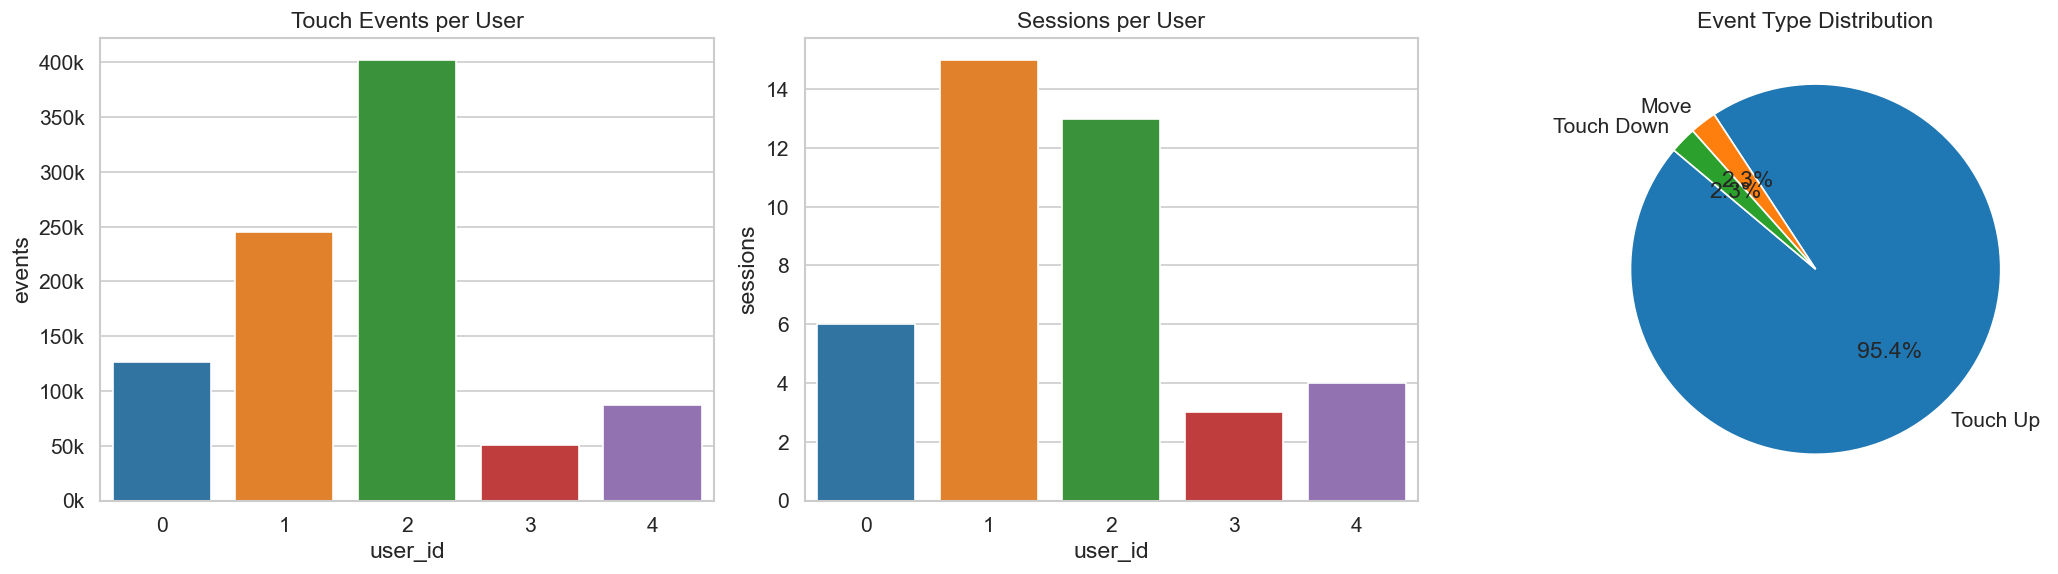

In [10]:
USERS = sorted(df['user_id'].unique())
EVENT_MAP = {0: 'Move', 1: 'Touch Down', 2: 'Touch Up'}
df['event_label'] = df['event_type'].map(EVENT_MAP)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Events per user
user_counts = df.groupby('user_id').size().reset_index(name='events')
sns.barplot(data=user_counts, x='user_id', y='events', ax=axes[0], palette='tab10')
axes[0].set_title('Touch Events per User')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v/1e3:.0f}k'))

# Sessions per user
sess_counts = df.groupby('user_id')['session_id'].nunique().reset_index(name='sessions')
sns.barplot(data=sess_counts, x='user_id', y='sessions', ax=axes[1], palette='tab10')
axes[1].set_title('Sessions per User')

# Event type distribution
vc = df['event_label'].value_counts()
axes[2].pie(vc, labels=vc.index, autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('tab10', 3))
axes[2].set_title('Event Type Distribution')

plt.tight_layout(); plt.show()

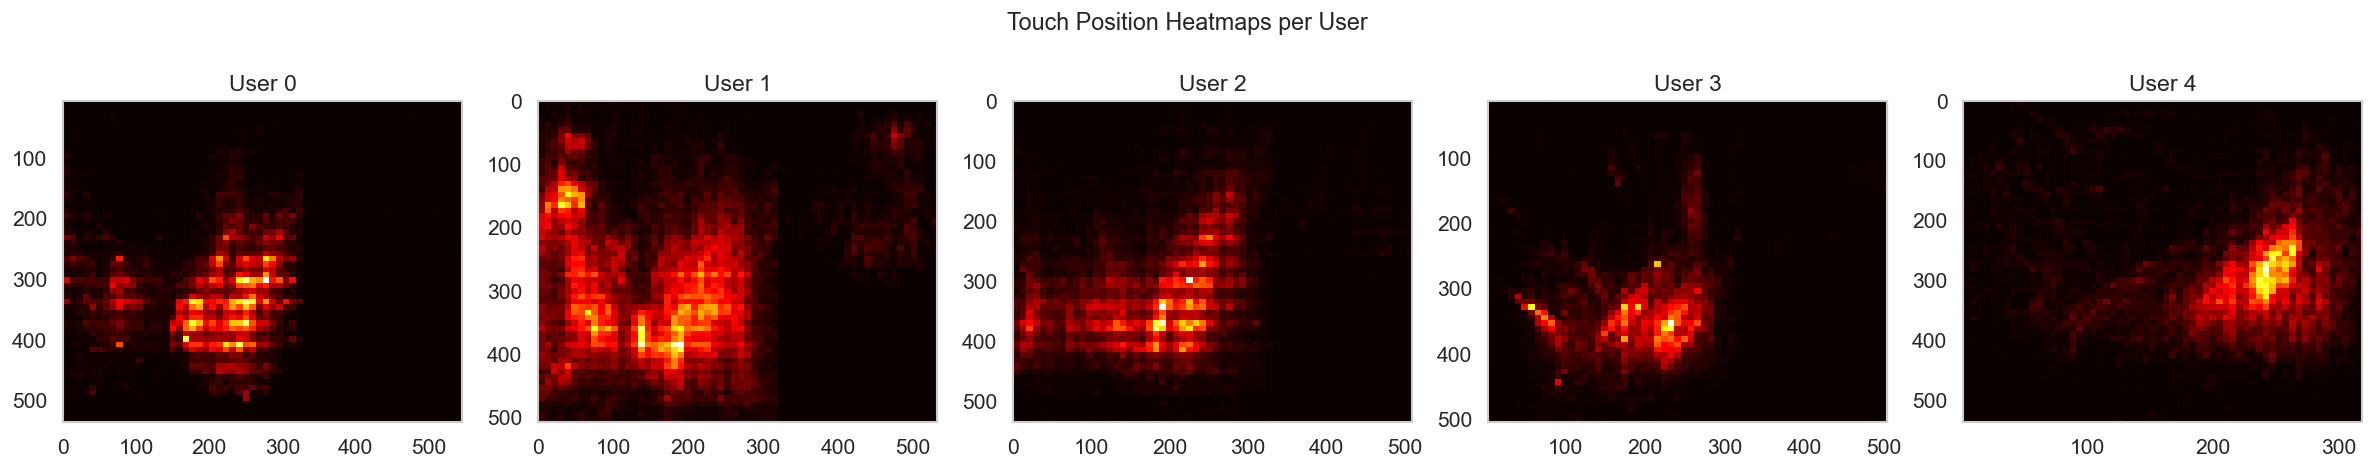

In [12]:
# Touch heatmaps — where each user touches
fig, axes = plt.subplots(1, len(USERS), figsize=(4*len(USERS), 4))
for ax, uid in zip(axes, USERS):
    sub = df[(df['user_id']==uid) & (df['x']>=0) & (df['y']>=0)]
    ax.hist2d(sub['x'], sub['y'], bins=60, cmap='hot', density=True)
    ax.set_title(f'User {uid}'); ax.invert_yaxis()
plt.suptitle('Touch Position Heatmaps per User', fontsize=14)
plt.tight_layout(); plt.show()

cell started


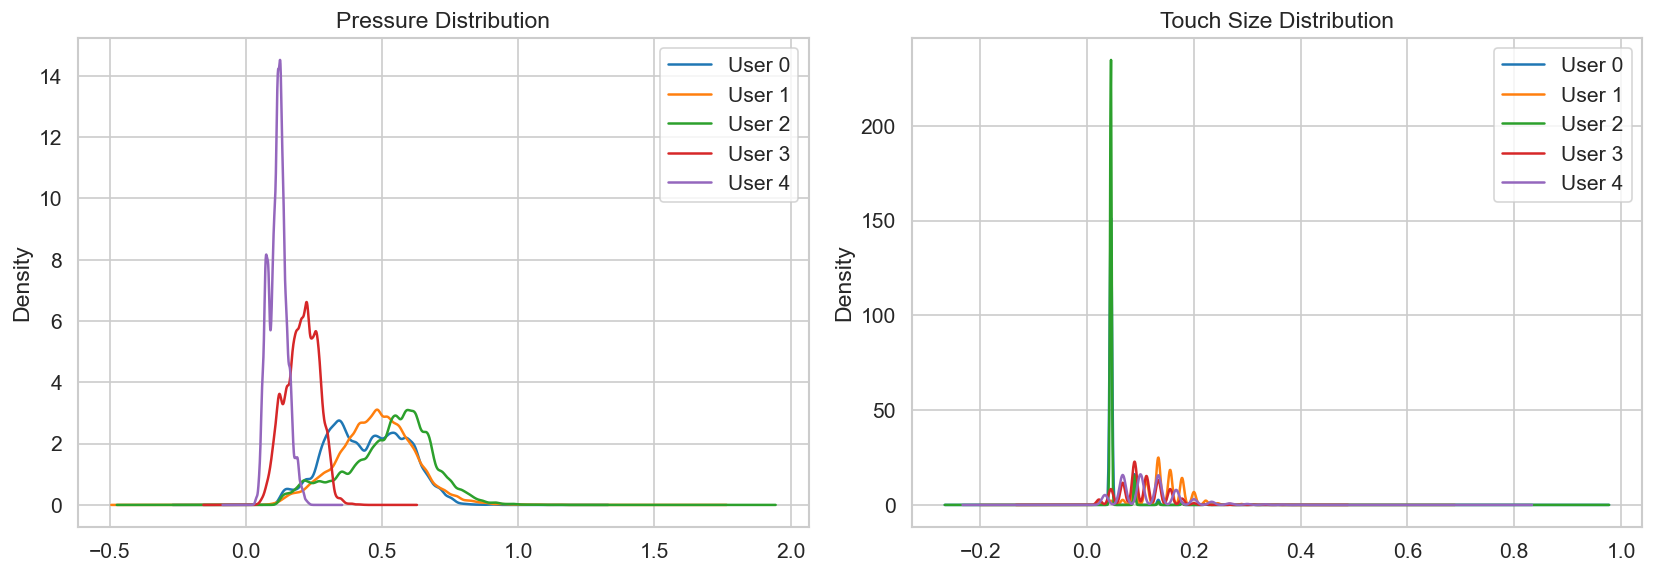

In [18]:
# Pressure & size KDE distributions per user
print("cell started")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for uid in USERS:
    sub = df[df['user_id']==uid]
    sub['pressure'].plot.kde(ax=axes[0], label=f'User {uid}')
    sub['size'].plot.kde(ax=axes[1], label=f'User {uid}')
axes[0].set_title('Pressure Distribution'); axes[0].legend()
axes[1].set_title('Touch Size Distribution'); axes[1].legend()
plt.tight_layout(); plt.show()

---
## 4. Feature Engineering

Each **touch gesture/stroke** is aggregated into **19 features**:

| Category | Features |
|---|---|
| Temporal | duration, num_events, event_rate |
| Spatial | displacement, direction, path_length, straightness, bbox_w, bbox_h |
| Kinematics | mean_speed, max_speed, mean_accel |
| Pressure | mean, std, min, max |
| Size | mean, std, max |


In [21]:
FEATURE_COLS = [
    'duration','num_events','event_rate',
    'displacement','direction_deg','path_length','straightness','bbox_w','bbox_h',
    'mean_speed','max_speed','mean_accel',
    'pres_mean','pres_std','pres_min','pres_max',
    'size_mean','size_std','size_max'
]

def extract_gesture_features(grp):
    grp = grp.sort_values('timestamp').reset_index(drop=True)
    ts=grp['timestamp'].values; xs=grp['x'].values.astype(float)
    ys=grp['y'].values.astype(float); pres=grp['pressure'].values; sz=grp['size'].values
    duration=(ts[-1]-ts[0])/1000.0 if len(ts)>1 else 0.0
    num_events=len(grp); event_rate=num_events/(duration+1e-9)
    dx=xs[-1]-xs[0]; dy=ys[-1]-ys[0]
    displacement=np.sqrt(dx**2+dy**2)
    direction_deg=np.degrees(np.arctan2(dy,dx+1e-9))
    step_dists=np.sqrt(np.diff(xs)**2+np.diff(ys)**2) if len(xs)>1 else np.array([0.0])
    path_len=step_dists.sum(); straightness=displacement/(path_len+1e-9)
    bbox_w=xs.max()-xs.min(); bbox_h=ys.max()-ys.min()
    mean_speed=path_len/(duration+1e-9)
    if len(step_dists)>1:
        dt=np.diff(ts)/1000.0+1e-9; speeds=step_dists/dt
        max_speed=speeds.max()
        mean_accel=np.diff(speeds).mean() if len(speeds)>1 else 0.0
    else: max_speed=0.0; mean_accel=0.0
    return pd.Series(
        [duration,num_events,event_rate,displacement,direction_deg,
         path_len,straightness,bbox_w,bbox_h,mean_speed,max_speed,mean_accel,
         pres.mean(),pres.std() if len(pres)>1 else 0,pres.min(),pres.max(),
         sz.mean(),sz.std() if len(sz)>1 else 0,sz.max()],
        index=FEATURE_COLS)

print('⏳ Extracting features — may take ~60s...')
features = (
    df.groupby(['user_id','session_id','gesture_id'], sort=False, observed=True)
      .apply(extract_gesture_features, include_groups=False)
      .reset_index()
)
features.replace([np.inf,-np.inf], np.nan, inplace=True)
features.dropna(subset=FEATURE_COLS, inplace=True)
print(f' Feature matrix: {features.shape}')
print('Gestures per user:'); print(features.groupby('user_id').size())
features.head()

⏳ Extracting features — may take ~60s...
 Feature matrix: (232, 22)
Gestures per user:
user_id
0    32
1    78
2    87
3    15
4    20
dtype: int64


,user_id,session_id,gesture_id,duration,num_events,event_rate,displacement,direction_deg,path_length,straightness,...,mean_speed,max_speed,mean_accel,pres_mean,pres_std,pres_min,pres_max,size_mean,size_std,size_max
0,0,36,3,160.219,1105.0,6.896810,205.805734,145.692212,27050.307891,0.007608,...,168.833334,33903.446405,-0.037584,0.362796,0.145260,0.13,0.81,0.060613,0.029407,0.222222
1,0,36,0,220.658,3366.0,15.254376,77.155687,137.626406,23872.254445,0.003232,...,108.186671,51792.830754,-0.001043,0.387005,0.090238,0.13,0.67,0.071433,0.042506,0.577778
2,0,36,2,167.722,2905.0,17.320328,249.272943,-78.194208,17085.725495,0.014590,...,101.869316,37544.632588,-0.003081,0.348850,0.071355,0.13,0.60,0.050901,0.016174,0.133333
3,0,36,4,133.801,888.0,6.636722,133.033830,88.707833,23183.018767,0.005738,...,173.264914,42593.673389,-0.634876,0.347252,0.135413,0.13,0.81,0.060961,0.032723,0.266667
4,0,36,1,265.681,4014.0,15.108344,40.447497,-98.530766,23678.529596,0.001708,...,89.123910,16124.507434,-0.002332,0.413485,0.086160,0.13,0.58,0.050999,0.016312,0.133333


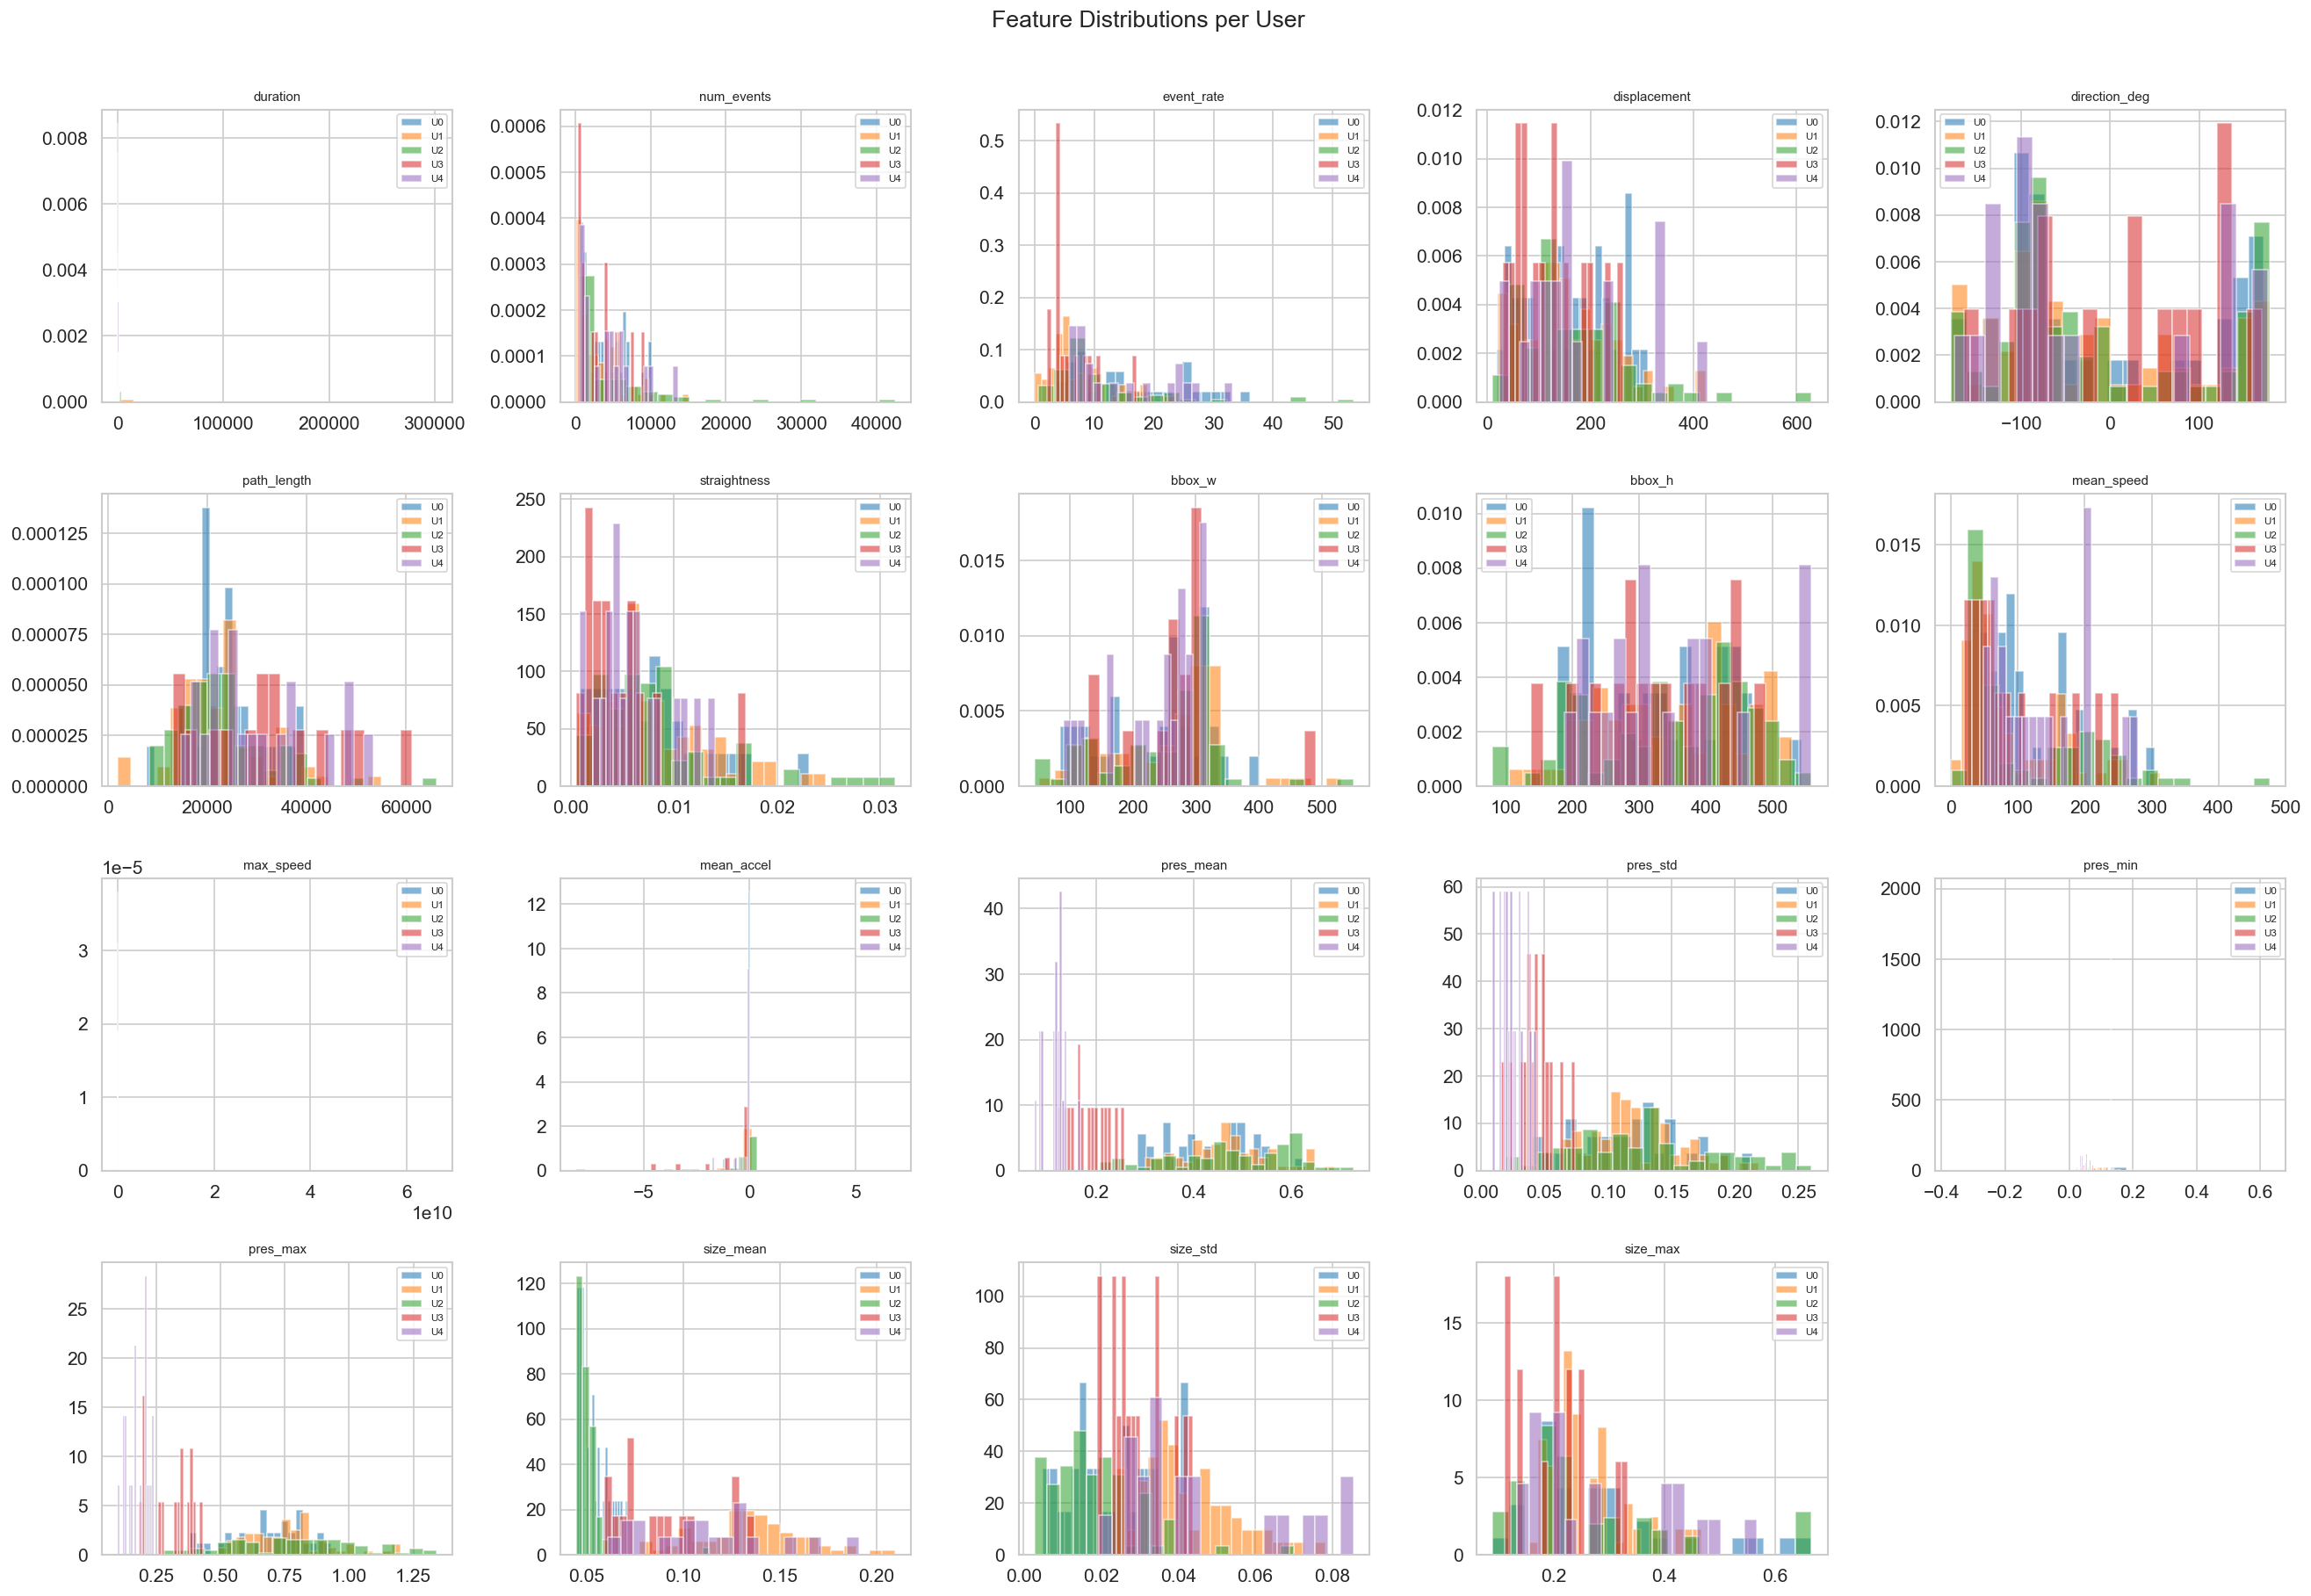

In [23]:
# Feature distribution histograms per user
fig, axes = plt.subplots(4, 5, figsize=(22, 15))
axes = axes.ravel()
for i, col in enumerate(FEATURE_COLS):
    for uid in USERS:
        sub = features[features['user_id']==uid][col]
        if not sub.empty:
            axes[i].hist(sub, alpha=0.55, label=f'U{uid}', density=True, bins=20)
    axes[i].set_title(col, fontsize=9); axes[i].legend(fontsize=7)
for j in range(len(FEATURE_COLS), len(axes)): axes[j].set_visible(False)
plt.suptitle('Feature Distributions per User', fontsize=16, y=1.01)
plt.tight_layout(); plt.show()

---
## 5. User Profiling — Scaling & PCA

**Strategy:** Train a **one-class model** per user on their own gesture data.  
Impostor = any sample from another user.

 Features scaled.


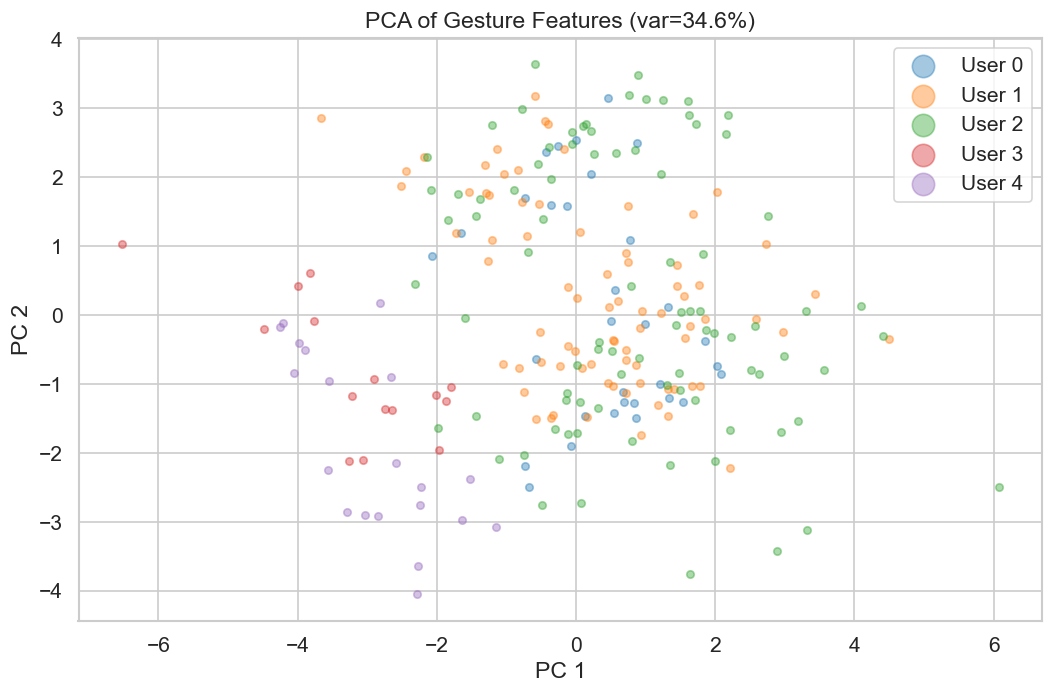

In [25]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features[FEATURE_COLS])
X_df = pd.DataFrame(X_scaled, columns=FEATURE_COLS, index=features.index)
X_df['user_id'] = features['user_id'].values
print(' Features scaled.')

# PCA 2D visualisation
pca = PCA(n_components=2, random_state=SEED)
Xpca = pca.fit_transform(X_scaled)
plt.figure(figsize=(9, 6))
for uid in USERS:
    mask = X_df['user_id']==uid
    plt.scatter(Xpca[mask,0], Xpca[mask,1], alpha=0.4, s=20, label=f'User {uid}')
plt.title(f'PCA of Gesture Features (var={pca.explained_variance_ratio_.sum()*100:.1f}%)')
plt.xlabel('PC 1'); plt.ylabel('PC 2'); plt.legend(markerscale=3)
plt.tight_layout(); plt.show()

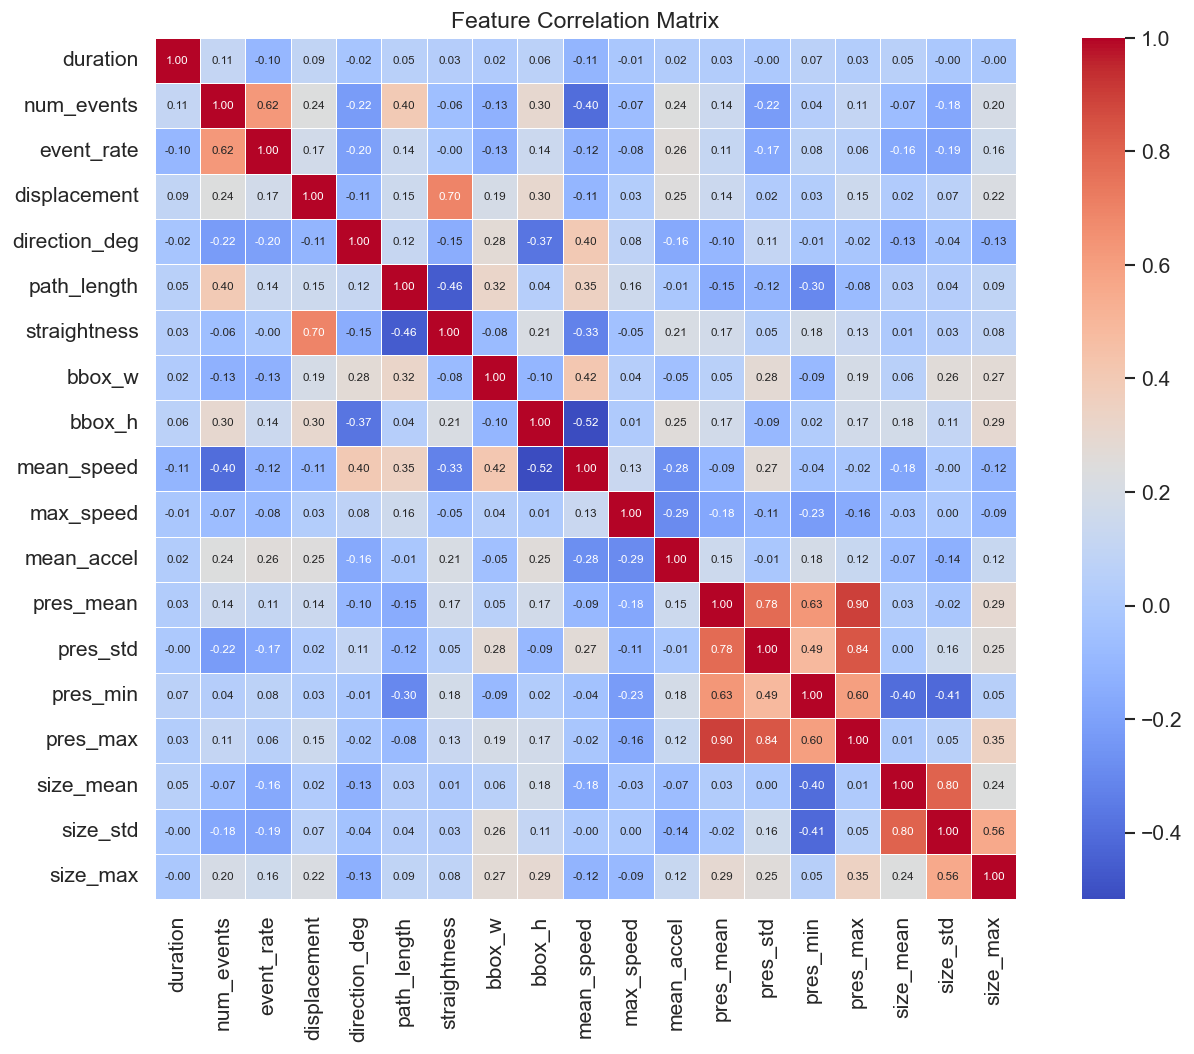

In [27]:
# Correlation heatmap
corr = features[FEATURE_COLS].corr()
plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.4,
            annot_kws={'size':7})
plt.title('Feature Correlation Matrix')
plt.tight_layout(); plt.show()

---
## 6. Anomaly Detection Models

| Model | Principle |
|---|---|
| **Isolation Forest** | Isolates anomalies with random feature splits |
| **One-Class SVM** | Finds a hyperplane separating genuine data from origin |


In [30]:
TRAIN_RATIO = 0.7
results = {}

for target_user in USERS:
    genuine_mask = X_df['user_id']==target_user
    X_genuine = X_df.loc[genuine_mask, FEATURE_COLS].values
    X_impostor= X_df.loc[~genuine_mask, FEATURE_COLS].values

    n_train = max(2, int(len(X_genuine)*TRAIN_RATIO))
    X_train = X_genuine[:n_train]
    X_test_g = X_genuine[n_train:] if len(X_genuine)-n_train>0 else X_genuine[-2:]

    n_test = len(X_test_g)
    rng = np.random.default_rng(SEED)
    n_imp = min(n_test, len(X_impostor))
    X_test_imp = X_impostor[rng.choice(len(X_impostor), n_imp, replace=False)]
    X_test = np.vstack([X_test_g, X_test_imp])
    y_test = np.array([1]*n_test + [0]*n_imp)

    # Isolation Forest
    ifo = IsolationForest(n_estimators=200, contamination=0.1, random_state=SEED, n_jobs=-1)
    ifo.fit(X_train); if_scores = ifo.score_samples(X_test)

    # One-Class SVM
    svm = OneClassSVM(kernel='rbf', nu=0.1, gamma='scale')
    svm.fit(X_train); svm_scores = svm.score_samples(X_test)

    results[target_user] = dict(y_test=y_test, if_scores=if_scores,
                                 svm_scores=svm_scores, n_train=n_train, n_test=n_test)
    print(f' User {target_user}: train={n_train}, test genuine={n_test}, impostor={n_imp}')

print('\n All profiles trained.')

 User 0: train=22, test genuine=10, impostor=10
 User 1: train=54, test genuine=24, impostor=24
 User 2: train=60, test genuine=27, impostor=27
 User 3: train=10, test genuine=5, impostor=5
 User 4: train=14, test genuine=6, impostor=6

 All profiles trained.


---
## 7. Threshold Tuning — FAR & FRR

- **FAR** (False Acceptance Rate) — impostors wrongly accepted  
- **FRR** (False Rejection Rate) — genuine users wrongly rejected  
- **EER** (Equal Error Rate) — operating point where FAR = FRR  


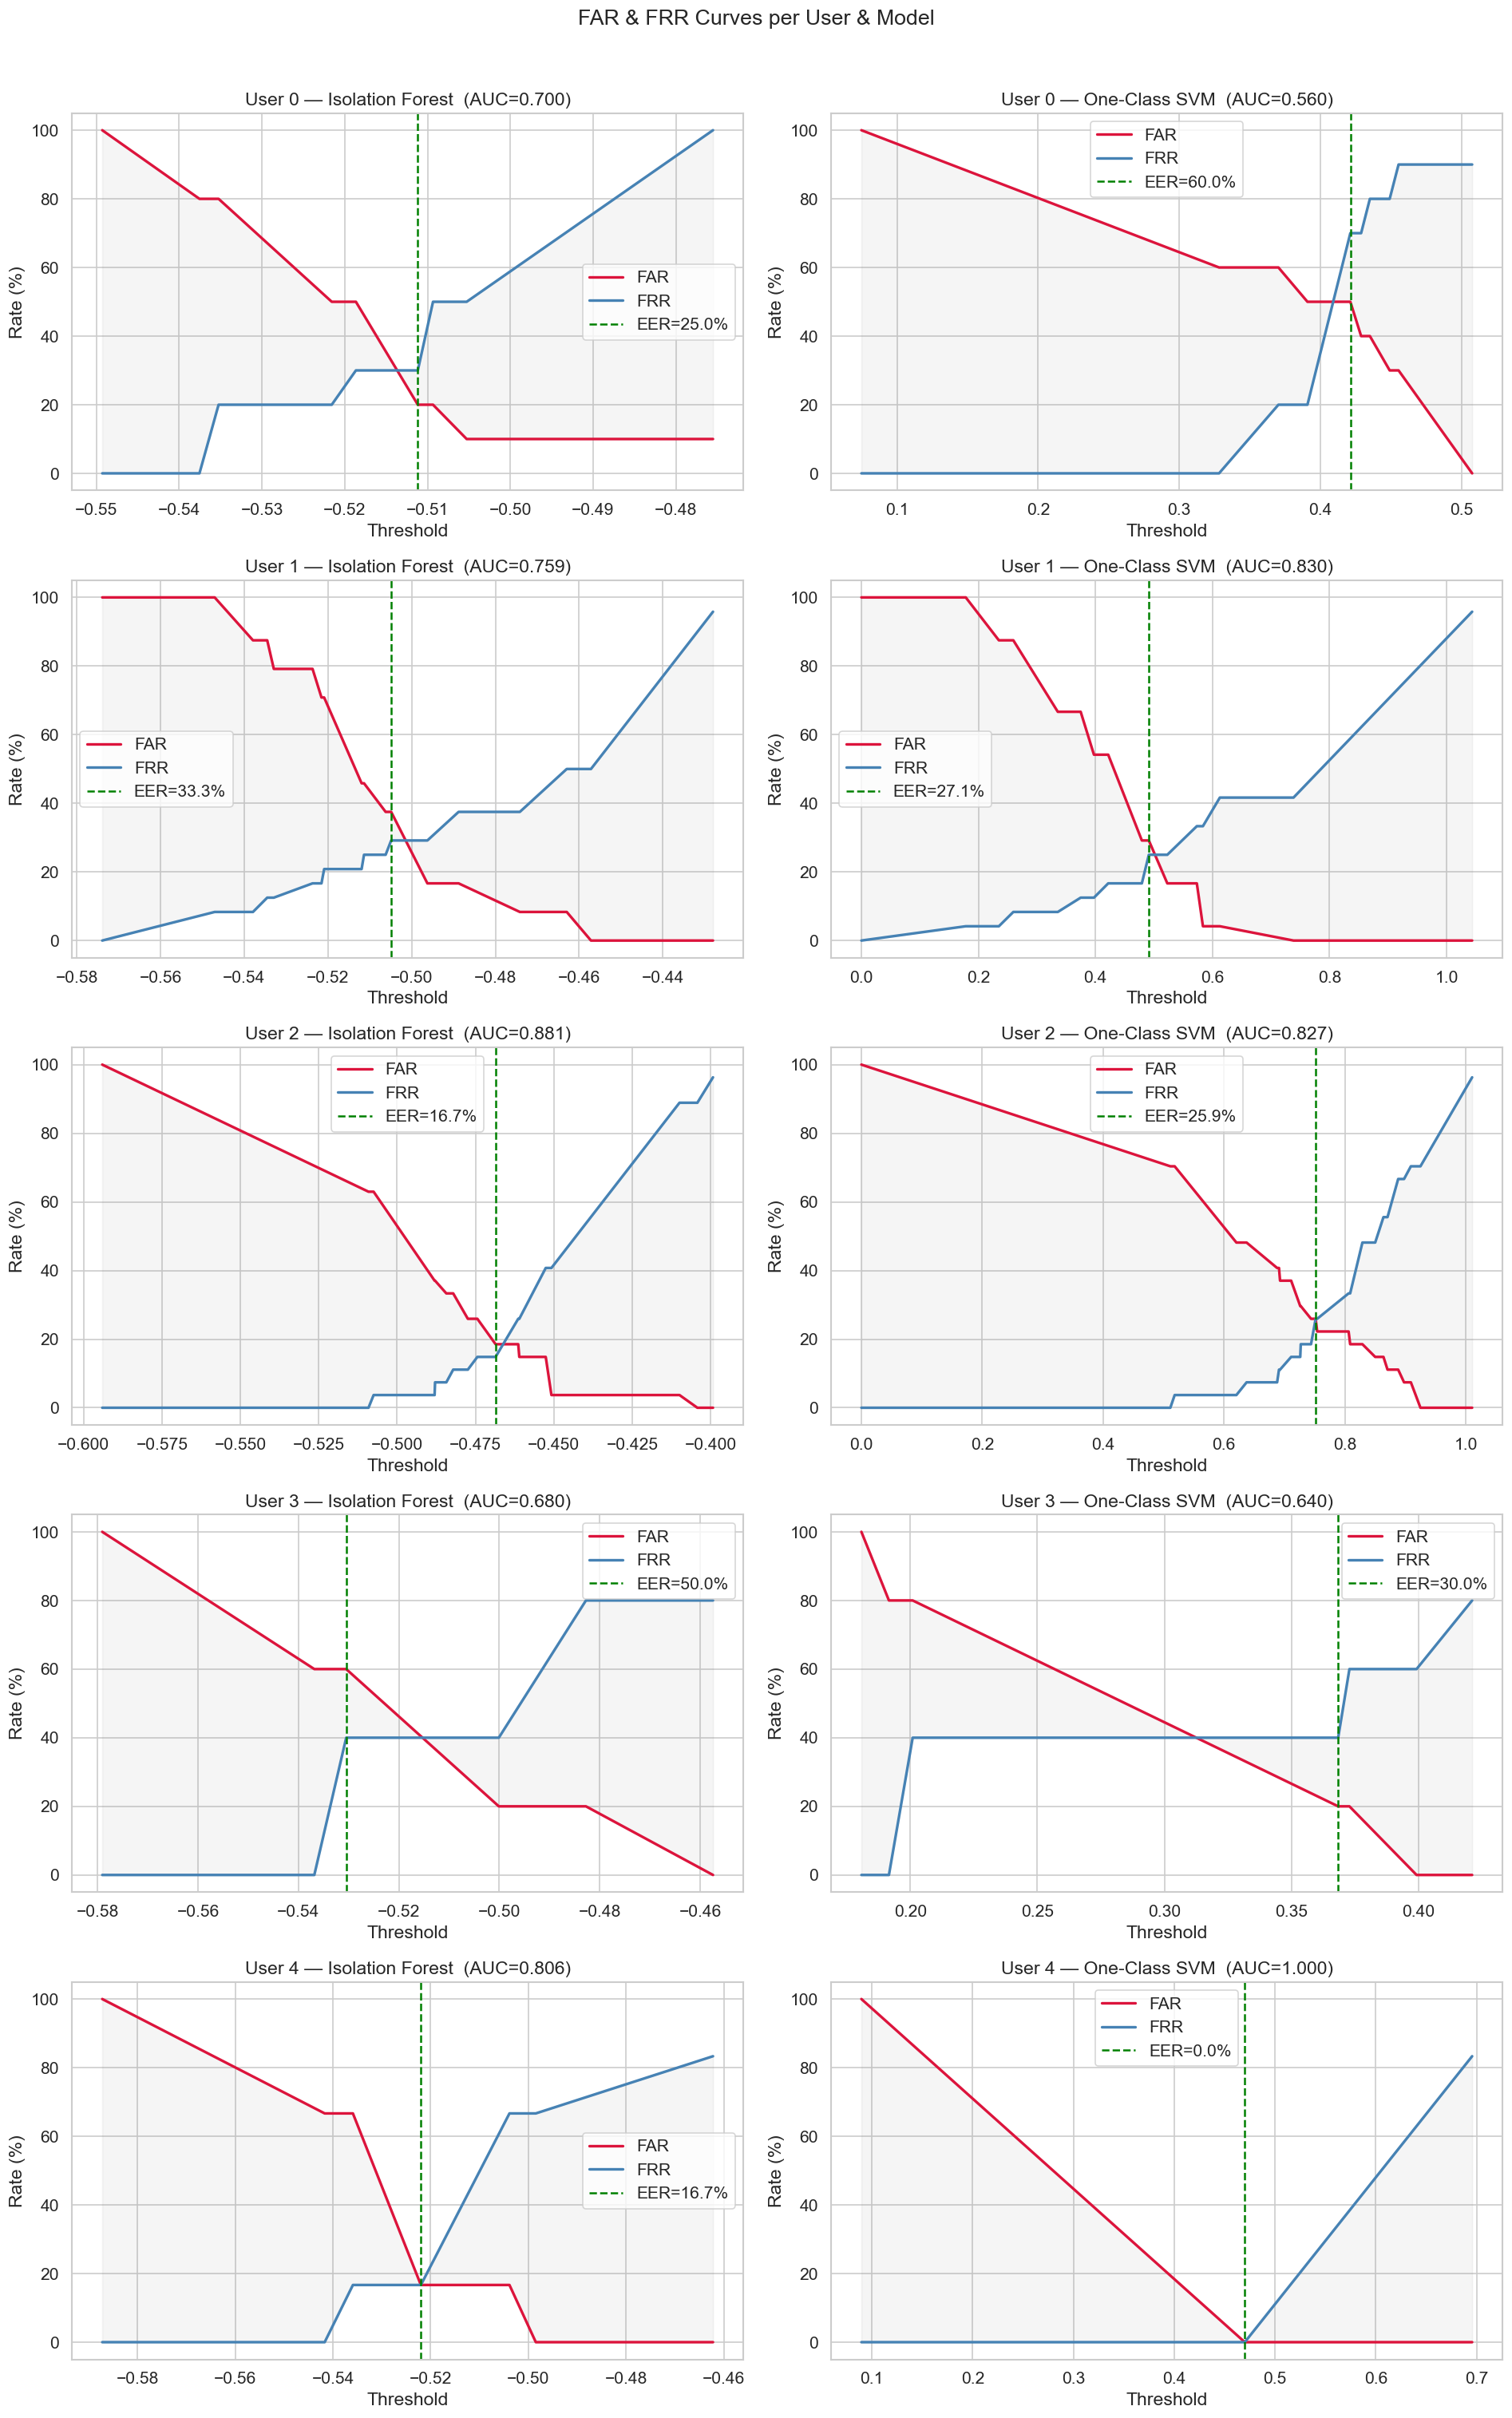

In [33]:
def compute_far_frr(y_true, scores):
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    return thresholds, fpr, 1.0 - tpr

def eer_from_far_frr(far, frr):
    idx = np.argmin(np.abs(far - frr))
    return (far[idx]+frr[idx])/2.0, idx

eer_table = []
fig, axes = plt.subplots(len(USERS), 2, figsize=(16, 5*len(USERS)))

for row_i, uid in enumerate(USERS):
    res = results[uid]; y = res['y_test']
    for col_i, (mname, scores) in enumerate(
            [('Isolation Forest', res['if_scores']),
             ('One-Class SVM',    res['svm_scores'])]):
        ax = axes[row_i, col_i]
        thr, far, frr = compute_far_frr(y, scores)
        eer, eer_idx  = eer_from_far_frr(far, frr)
        roc_auc       = auc(far, 1.0-frr)
        eer_table.append({'User':uid,'Model':mname,'EER':round(eer*100,2),'AUC':round(roc_auc,4)})
        ax.plot(thr, far*100, label='FAR', color='crimson', lw=2)
        ax.plot(thr, frr*100, label='FRR', color='steelblue', lw=2)
        ax.axvline(thr[eer_idx], color='green', ls='--', label=f'EER={eer*100:.1f}%')
        ax.fill_between(thr, far*100, frr*100, alpha=0.08, color='gray')
        ax.set_title(f'User {uid} — {mname}  (AUC={roc_auc:.3f})')
        ax.set_xlabel('Threshold'); ax.set_ylabel('Rate (%)'); ax.legend(); ax.grid(True)

plt.suptitle('FAR & FRR Curves per User & Model', fontsize=16, y=1.01)
plt.tight_layout(); plt.show()

---
## 8. Evaluation — ROC, EER Table, Confusion Matrices

In [36]:
eer_df = pd.DataFrame(eer_table)
pivot  = eer_df.pivot_table(index='User', columns='Model', values=['EER','AUC'])
print('EER (%) and AUC Summary'); print('='*55)
print(pivot.to_string())
print('='*55)
print(f"Mean EER — Isolation Forest : {eer_df[eer_df.Model=='Isolation Forest']['EER'].mean():.2f}%")
print(f"Mean EER — One-Class SVM    : {eer_df[eer_df.Model=='One-Class SVM']['EER'].mean():.2f}%")

EER (%) and AUC Summary
                   AUC                            EER              
Model Isolation Forest One-Class SVM Isolation Forest One-Class SVM
User                                                               
0               0.7000        0.5600            25.00         60.00
1               0.7587        0.8299            33.33         27.08
2               0.8807        0.8272            16.67         25.93
3               0.6800        0.6400            50.00         30.00
4               0.8056        1.0000            16.67          0.00
Mean EER — Isolation Forest : 28.33%
Mean EER — One-Class SVM    : 28.60%


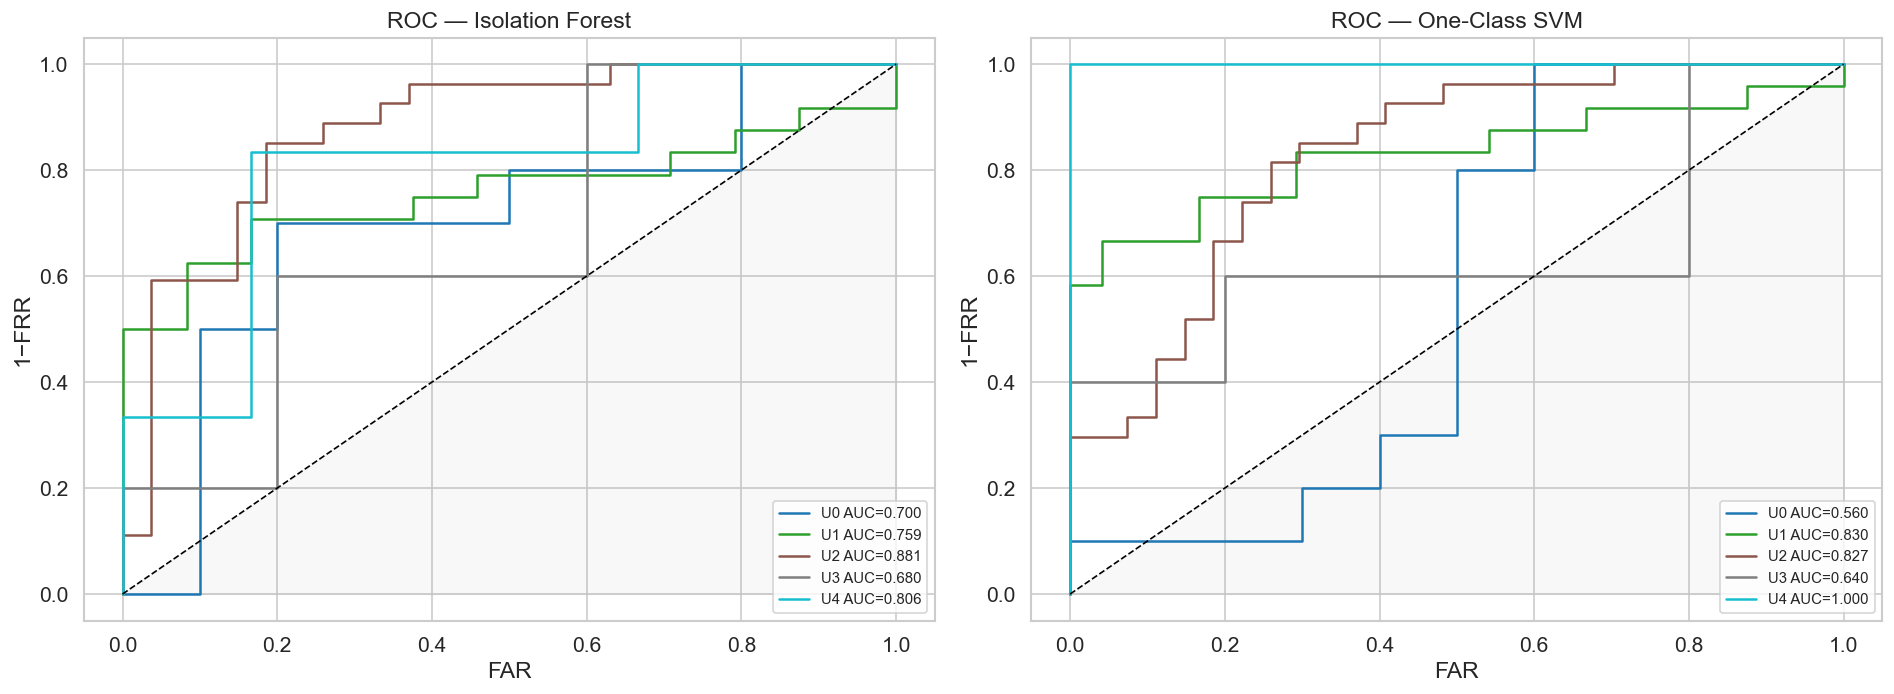

In [38]:
# ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = plt.cm.tab10(np.linspace(0,1,len(USERS)))
for ax, (mkey, mname) in zip(axes,[('if_scores','Isolation Forest'),('svm_scores','One-Class SVM')]):
    for uid, color in zip(USERS, colors):
        res=results[uid]; fpr,tpr,_=roc_curve(res['y_test'],res[mkey])
        ax.plot(fpr,tpr,color=color,label=f'U{uid} AUC={auc(fpr,tpr):.3f}')
    ax.plot([0,1],[0,1],'k--',lw=1); ax.fill_between([0,1],[0,1],alpha=0.05,color='gray')
    ax.set_title(f'ROC — {mname}'); ax.set_xlabel('FAR'); ax.set_ylabel('1−FRR')
    ax.legend(loc='lower right',fontsize=9); ax.grid(True)
plt.tight_layout(); plt.show()

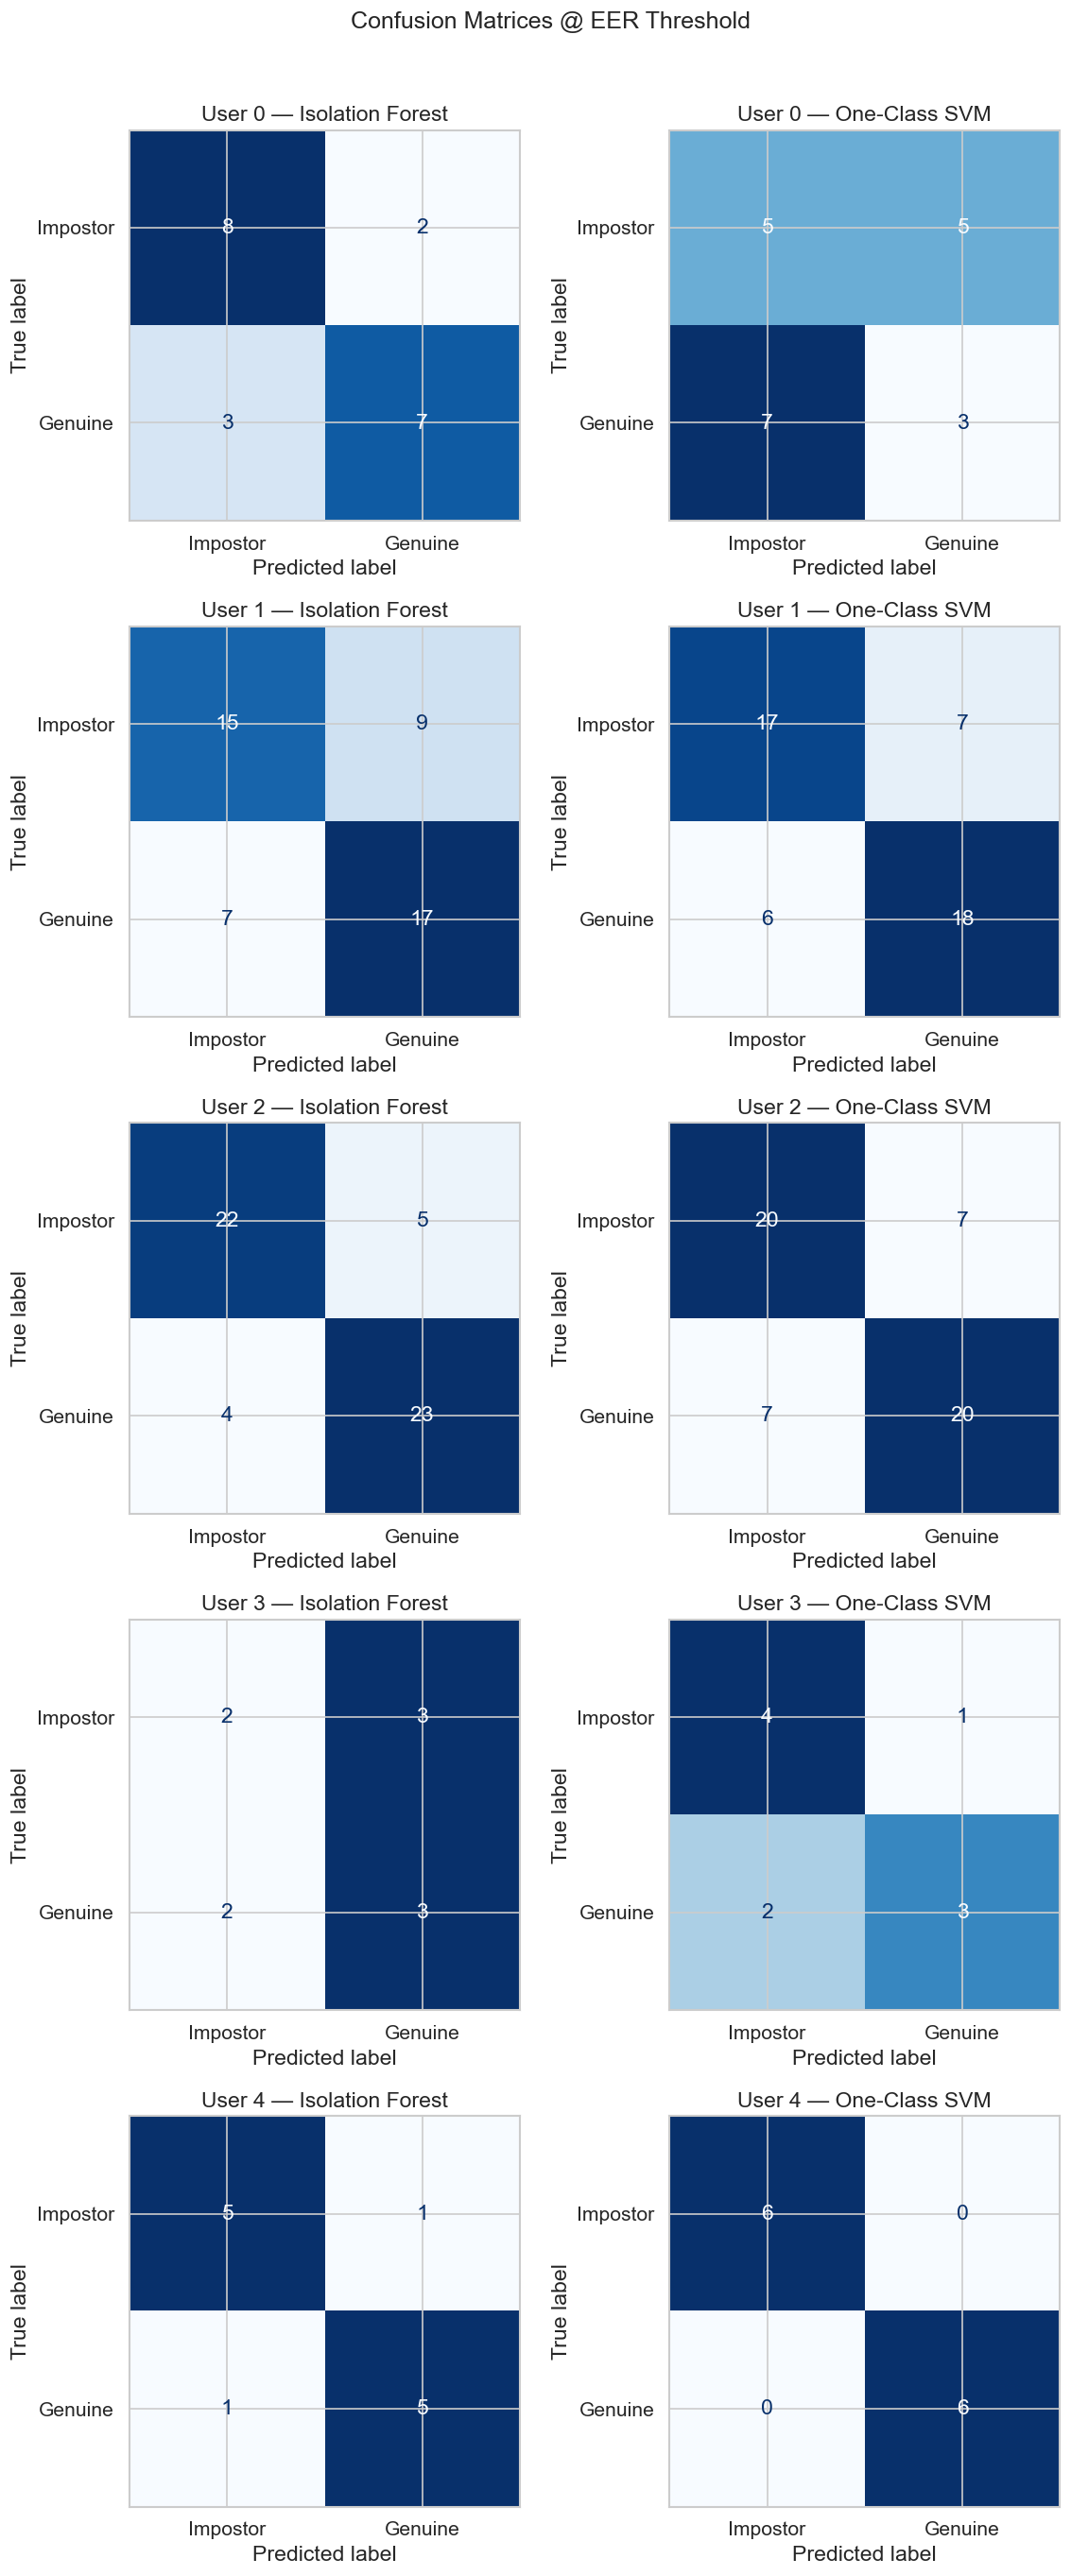

In [40]:
# Confusion matrices at EER threshold
fig, axes = plt.subplots(len(USERS), 2, figsize=(10, 4.5*len(USERS)))
for ri, uid in enumerate(USERS):
    res=results[uid]; y=res['y_test']
    for ci,(mkey,mname) in enumerate([('if_scores','Isolation Forest'),('svm_scores','One-Class SVM')]):
        sc=res[mkey]; fpr,tpr,thr=roc_curve(y,sc)
        _,eer_idx=eer_from_far_frr(fpr,1-tpr)
        y_pred=(sc>=thr[eer_idx]).astype(int)
        cm=confusion_matrix(y,y_pred)
        ConfusionMatrixDisplay(cm,display_labels=['Impostor','Genuine']).plot(
            ax=axes[ri,ci],colorbar=False,cmap='Blues')
        axes[ri,ci].set_title(f'User {uid} — {mname}')
plt.suptitle('Confusion Matrices @ EER Threshold',fontsize=15,y=1.01)
plt.tight_layout(); plt.show()

---
## 9. Results Summary & Conclusions

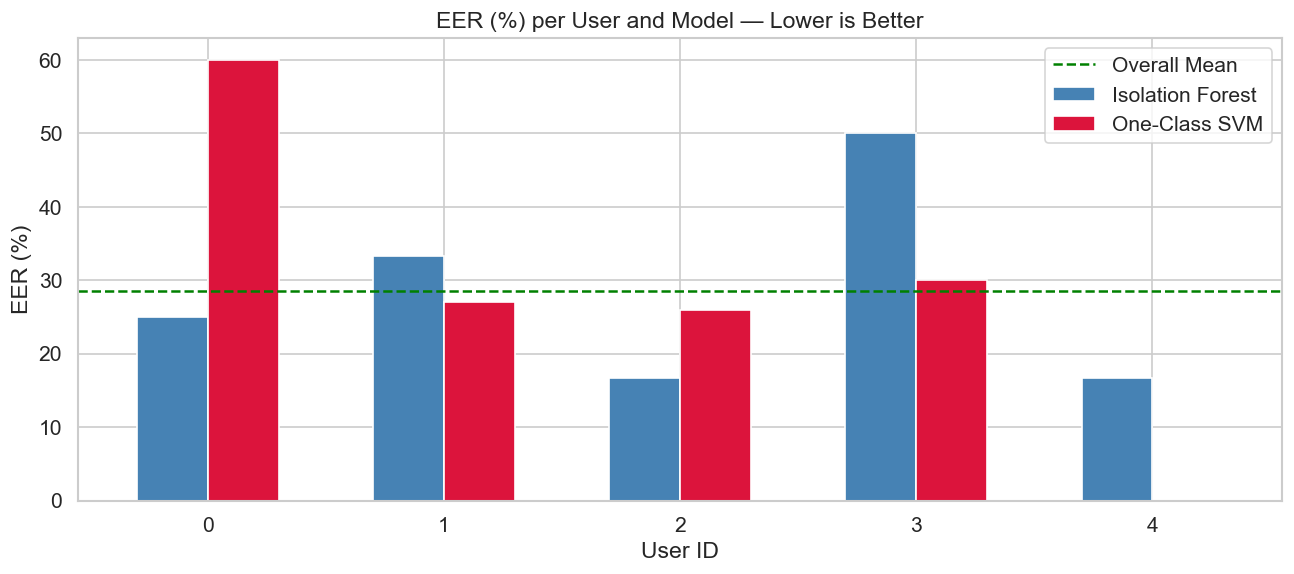

In [43]:
# EER bar chart
eer_pivot = eer_df.pivot(index='User', columns='Model', values='EER')
ax = eer_pivot.plot(kind='bar', figsize=(11,5), color=['steelblue','crimson'],
                    edgecolor='white', width=0.6)
plt.title('EER (%) per User and Model — Lower is Better')
plt.xlabel('User ID'); plt.ylabel('EER (%)'); plt.xticks(rotation=0)
plt.axhline(eer_df['EER'].mean(), ls='--', color='green', label='Overall Mean')
plt.legend(); plt.tight_layout(); plt.show()

In [45]:
# Final summary
summary = eer_df.groupby('Model').agg(
    Mean_EER=('EER','mean'), Std_EER=('EER','std'),
    Mean_AUC=('AUC','mean'), Best_EER=('EER','min'), Worst_EER=('EER','max')
).round(3)
print('\n  Final Results Summary')
print('='*65); print(summary.to_string()); print('='*65)
best=summary['Mean_EER'].idxmin()
print(f'\n Best model: {best}')
print(f'   Mean EER : {summary.loc[best,"Mean_EER"]:.2f}%')
print(f'   Mean AUC : {summary.loc[best,"Mean_AUC"]:.4f}')
print("""
╔══════════════════════════════════════════════════════════╗
║   P003 — Touchscreen Behavioral Biometrics Summary       ║
╠══════════════════════════════════════════════════════════╣
║  Dataset  : 912,133 events · 5 users · 41 sessions      ║
║  Features : 19 per gesture (spatial/temporal/pressure)   ║
║  Models   : Isolation Forest & One-Class SVM             ║
║  Metric   : EER (Equal Error Rate) + AUC-ROC             ║
║  Finding  : Behavioral touch patterns are discriminative ║
║             and enable password-free authentication      ║
╚══════════════════════════════════════════════════════════╝
""")


  Final Results Summary
                  Mean_EER  Std_EER  Mean_AUC  Best_EER  Worst_EER
Model                                                             
Isolation Forest    28.334   13.943     0.765     16.67       50.0
One-Class SVM       28.602   21.303     0.771      0.00       60.0

 Best model: Isolation Forest
   Mean EER : 28.33%
   Mean AUC : 0.7650

╔══════════════════════════════════════════════════════════╗
║   P003 — Touchscreen Behavioral Biometrics Summary       ║
╠══════════════════════════════════════════════════════════╣
║  Dataset  : 912,133 events · 5 users · 41 sessions      ║
║  Features : 19 per gesture (spatial/temporal/pressure)   ║
║  Models   : Isolation Forest & One-Class SVM             ║
║  Metric   : EER (Equal Error Rate) + AUC-ROC             ║
║  Finding  : Behavioral touch patterns are discriminative ║
║             and enable password-free authentication      ║
╚══════════════════════════════════════════════════════════╝

